In [1]:
# Make energy histogram with channel pairs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [46]:
data_dir = 'D:/HWTriggerTestOn100_coinc.dat'

data = pd.DataFrame()
for chunk in pd.read_csv(data_dir, sep = '\t', header = None, dtype = np.float64, usecols = [3,4,8,9], chunksize=1000000):
    data = pd.concat([data, chunk], ignore_index = True)
data = np.asarray(data,)
print(data[0])
print(len(data))

[2.1060505e+01 1.3530600e+05 1.9419472e+01 4.7910000e+03]
1164182


In [47]:
coinc_list = [[] for lr in range(3072 * 3072)]
for row in data:
    if (row[1] - 131072) % 3072 < 3072:
        coinc_list[int(((row[1] - 131072) % 3072) * 3072 + (row[3] % 3072))].append([row[0], row[2]])


In [48]:
# Big histogram
bigenergylist = []
for lr in coinc_list:
    for row in lr:
        bigenergylist.append(row[0])
        bigenergylist.append(row[1])
print(len(bigenergylist))

2328364


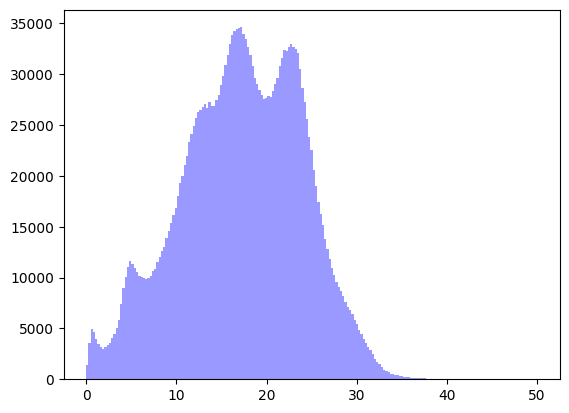

In [49]:
plt.hist(bigenergylist, bins = np.linspace(0, 50, 200), color = 'blue', alpha = 0.4)
plt.show()

In [31]:
for lr in range(3072 * 3072):
    if len(coinc_list[lr]) > 13:
        print(lr)

256064
700900
1496288
8321384


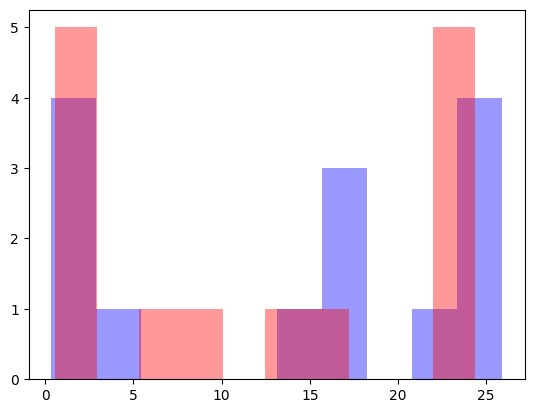

In [32]:
idl = 0
idr = 0

energiesL = []
energiesR = []
for row in coinc_list[700900]:
    energiesL.append(row[0])
    energiesR.append(row[1])

plt.hist(energiesL, color = 'blue', alpha = 0.4)
plt.hist(energiesR, color = 'red', alpha = 0.4)
plt.show()
